# Exploratory Data Analysis
## Urinary Biomarkers for Pancreatic Cancer

This notebook explores the dataset **before** any modeling: class balance, missing values, feature distributions, and how biomarker levels differ across diagnosis groups. The goal is to build intuition for the preprocessing and modeling decisions made in `src/preprocess.py` and `src/train.py`.

> **Note:** as documented in `data/README.md`, this notebook runs on a *synthetic* placeholder dataset (real schema, fabricated values) because this environment has no network access to download the real Kaggle/UCI dataset. Re-run this notebook after swapping in the real CSV.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_raw_data, DIAGNOSIS_LABELS

sns.set_theme(style="whitegrid")

df = load_raw_data()
df["diagnosis_label"] = df["diagnosis"].map(DIAGNOSIS_LABELS)
df.head()

[data_loader] Loaded existing dataset <- /home/user/Early-Stage-Pancreatic-Cancer-Detection-Using-Random-Forest-Classification/data/raw/urinary_biomarkers.csv (590 rows)


,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A,diagnosis_label
0,S0001,Cohort2,LIV,51.0,F,3,III,NaN,46.155378,1.230019,3.171010,11.050389,54.516278,16.196879,PDAC
1,S0002,Cohort1,ESP,68.0,F,2,NaN,Chronic pancreatitis,23.327976,0.292283,5.717457,17.146811,30.708237,14.029581,Benign
2,S0003,Cohort1,BPTB,63.0,F,3,II,NaN,97.980601,1.665327,5.232875,28.033576,97.501557,NaN,PDAC
3,S0004,Cohort2,BPTB,40.0,F,3,III,NaN,86.654876,0.322490,4.848226,25.431326,67.001841,12.458480,PDAC
4,S0005,Cohort2,ESP,59.0,M,1,NaN,NaN,55.370653,2.950464,1.181102,5.960726,9.035474,4.004988,Control


## 1. Shape, dtypes, and missing values

`stage` and `benign_sample_diagnosis` are expected to be mostly missing -- they're only filled in for PDAC / benign samples respectively (and are dropped before modeling as target leakage, see `preprocess.py`). `plasma_CA19_9` and `REG1A` have genuine missingness that `preprocess.py` imputes with the training-set median.

In [2]:
print(df.shape)
df.info()
print("\nMissing value counts:")
df.isna().sum().sort_values(ascending=False)

(590, 15)
<class 'pandas.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sample_id                590 non-null    str    
 1   patient_cohort           590 non-null    str    
 2   sample_origin            590 non-null    str    
 3   age                      590 non-null    float64
 4   sex                      590 non-null    str    
 5   diagnosis                590 non-null    int64  
 6   stage                    197 non-null    str    
 7   benign_sample_diagnosis  207 non-null    str    
 8   plasma_CA19_9            518 non-null    float64
 9   creatinine               590 non-null    float64
 10  LYVE1                    590 non-null    float64
 11  REG1B                    590 non-null    float64
 12  TFF1                     590 non-null    float64
 13  REG1A                    318 non-null    float64
 14  diagnosis_label          59

stage                      393
benign_sample_diagnosis    383
REG1A                      272
plasma_CA19_9               72
sample_origin                0
patient_cohort               0
sample_id                    0
diagnosis                    0
sex                          0
age                          0
creatinine                   0
LYVE1                        0
REG1B                        0
TFF1                         0
diagnosis_label              0
dtype: int64

## 2. Class balance

The three diagnosis classes are only mildly imbalanced, which is why `train.py` uses SMOTE + `class_weight='balanced'` rather than more aggressive rebalancing.

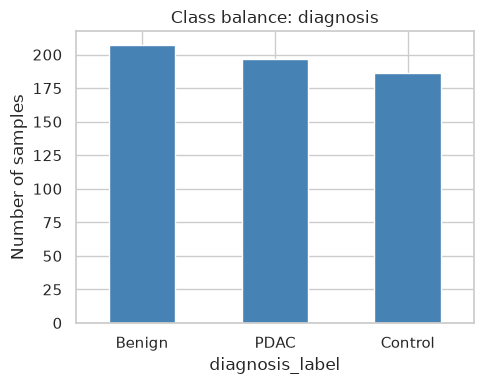

diagnosis_label
Benign     207
PDAC       197
Control    186
Name: count, dtype: int64

In [3]:
counts = df["diagnosis_label"].value_counts()
ax = counts.plot(kind="bar", color="steelblue", figsize=(5, 4))
ax.set_title("Class balance: diagnosis")
ax.set_ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
counts

## 3. Biomarker distributions by diagnosis

This is the core clinical question: do biomarker levels actually separate PDAC from Control/Benign? Boxplots make overlapping-but-shifted distributions easy to see.

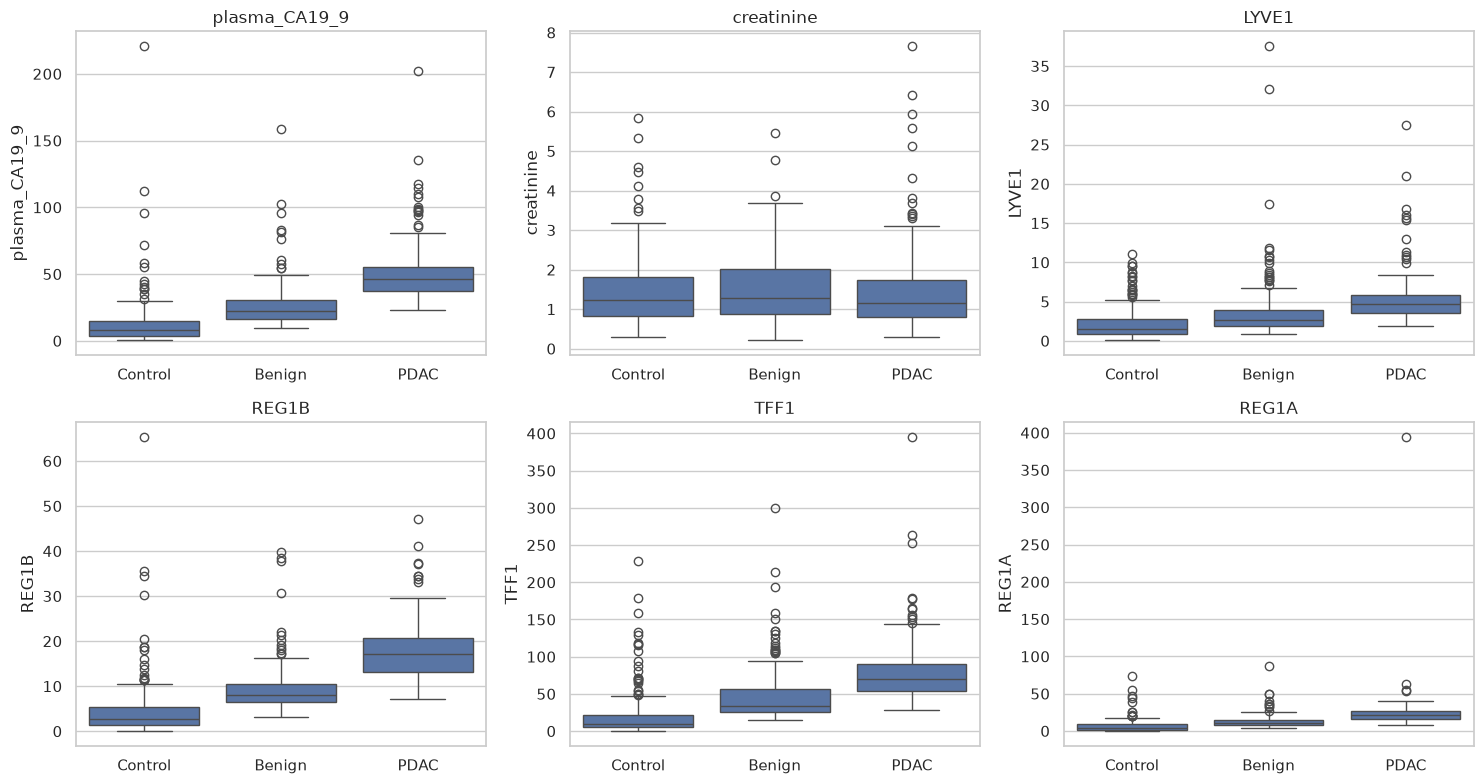

In [4]:
biomarkers = ["plasma_CA19_9", "creatinine", "LYVE1", "REG1B", "TFF1", "REG1A"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, biomarkers):
    sns.boxplot(data=df, x="diagnosis_label", y=col, ax=ax, order=["Control", "Benign", "PDAC"])
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Observation:** PDAC samples tend to have visibly higher median REG1B, TFF1, and CA19-9 than Control -- this lines up with the feature-importance ranking produced later by the trained Random Forest in `reports/feature_importance.png`.

## 4. Correlation between numeric features

Useful for spotting redundant features (Random Forest handles correlated features fine, but it's still worth knowing about for the writeup).

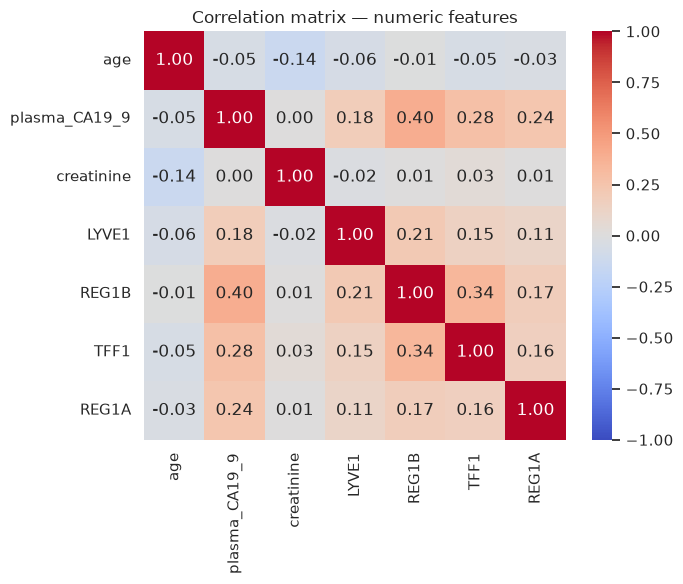

In [5]:
numeric_cols = ["age"] + biomarkers
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

## 5. Age and sex distribution

Sanity-checking demographic features for anything unusual (e.g. an age skew that could confound results).

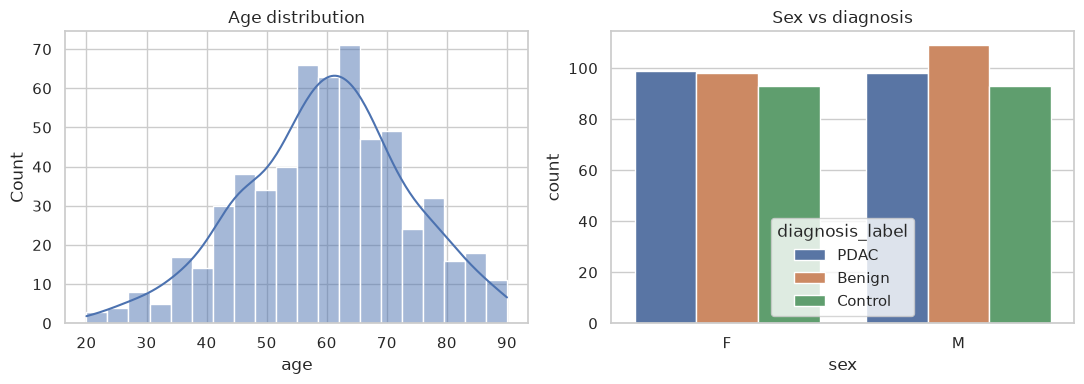

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["age"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age distribution")

sns.countplot(data=df, x="sex", hue="diagnosis_label", ax=axes[1])
axes[1].set_title("Sex vs diagnosis")
plt.tight_layout()
plt.show()

## Takeaways for modeling

1. Classes are only mildly imbalanced -> SMOTE + `class_weight='balanced'` is sufficient, no need for aggressive undersampling.
2. `plasma_CA19_9` and `REG1A` need missing-value imputation.
3. `stage` and `benign_sample_diagnosis` must be dropped -- they leak the target.
4. REG1B, TFF1, and CA19-9 visually separate PDAC from Control the most -- consistent with what the trained Random Forest later ranks as most important (see `reports/feature_importance.png`).